# 08 · BNNs with TensorFlow Probability

*Companion notebook for the chapter section* **Software for BNN — TensorFlow**

TensorFlow Probability (TFP) provides probabilistic layers, so a BNN can be written in a few lines of Keras. We build a network that models **both** kinds of uncertainty:

* **epistemic** — `DenseVariational` layers keep a Gaussian distribution over every weight (variational inference, as in notebook 06);
* **aleatoric** — the network outputs a whole Normal distribution $\mathcal N\big(\mu(x),\sigma(x)^2\big)$ whose noise level depends on $x$.

> **Setup.** TFP currently works with *Keras 2*, provided by the `tf-keras` package:
> `pip install tensorflow tensorflow-probability tf-keras`. The environment variable below must be set **before** TensorFlow is imported.

In [1]:
# On Google Colab or a fresh environment, uncomment the next line once:
# !pip install -q tensorflow tensorflow-probability tf-keras

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"          # use Keras 2 (tf_keras), required by TFP layers
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras as tfk

tfd, tfpl = tfp.distributions, tfp.layers
tf.random.set_seed(0); np.random.seed(0)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
print("TensorFlow", tf.__version__, "| TFP", tfp.__version__)

TensorFlow 2.21.0 | TFP 0.25.0


## 1. Data with input-dependent noise
The noise standard deviation grows with $|x|$, so the *aleatoric* uncertainty is not constant.

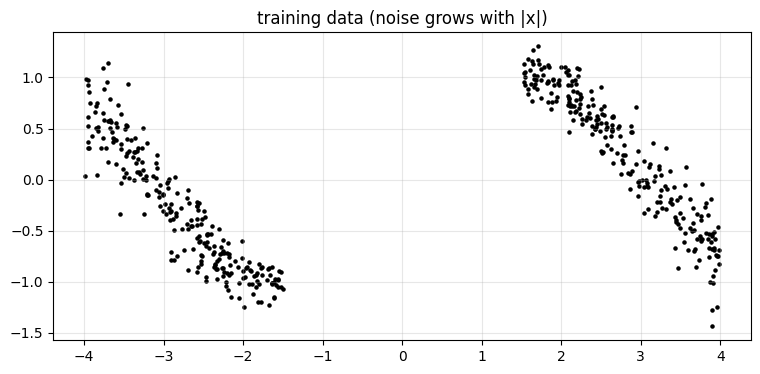

In [3]:
N = 500
x = np.concatenate([np.random.uniform(-4, -1.5, N // 2), np.random.uniform(1.5, 4, N // 2)]).astype("float32")
noise_sd = 0.03 + 0.06 * np.abs(x)
y = (np.sin(x) + noise_sd * np.random.randn(N)).astype("float32")
X, Y = x[:, None], y[:, None]
xg = np.linspace(-8, 8, 400, dtype="float32")[:, None]

plt.scatter(x, y, s=5, c="k"); plt.title("training data (noise grows with |x|)"); plt.show()

## 2. Posterior and prior over the weights

`DenseVariational` asks for two functions that build distributions over the layer's flattened kernel and bias:

* **posterior** $q(\mathbf w)$: an independent Normal per weight with trainable mean and (softplus-transformed) scale — the same mean-field family as notebook 06;
* **prior** $p(\mathbf w)$: a fixed $\mathcal N(0,1)$.

We use a **single hidden layer**: as notebook 06 showed, every extra weight adds KL cost, and with 500 points a deep mean-field BNN would be pushed back towards its prior.

`kl_weight = 1/N` spreads the KL term over the $N$ data points, exactly like dividing the ELBO by $N$ in notebook 06.

In [4]:
def posterior_mean_field(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    c = np.log(np.expm1(1.0))
    return tfk.Sequential([
        tfpl.VariableLayer(2 * n, dtype=dtype, initializer=tfk.initializers.RandomNormal(stddev=0.3)),
        tfpl.DistributionLambda(lambda t: tfd.Independent(
            tfd.Normal(loc=t[..., :n], scale=1e-5 + 0.02 * tf.nn.softplus(c + t[..., n:])),
            reinterpreted_batch_ndims=1)),
    ])

def prior_standard_normal(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return tfk.Sequential([
        tfpl.DistributionLambda(lambda t: tfd.Independent(
            tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=1.0), reinterpreted_batch_ndims=1)),
    ])

## 3. The model

The last layer outputs two numbers per input: a mean and a raw scale. `DistributionLambda` turns them into a Normal distribution, so the loss is simply the **negative log-likelihood** of the observed $y$ under that distribution. Keras adds the KL terms of the `DenseVariational` layers automatically.

In [5]:
def dense_var(units, activation=None, **kw):
    return tfpl.DenseVariational(units, posterior_mean_field, prior_standard_normal,
                                 kl_weight=1 / N, activation=activation, **kw)

model = tfk.Sequential([
    dense_var(24, "tanh", input_shape=(1,)),        # one hidden layer: few weights keep the KL cost manageable
    dense_var(2),
    tfpl.DistributionLambda(lambda t: tfd.Normal(loc=t[..., :1], scale=1e-3 + tf.math.softplus(t[..., 1:] - 2.0))),
])

negloglik = lambda y_true, dist: -dist.log_prob(y_true)
model.compile(optimizer=tfk.optimizers.Adam(learning_rate=0.02), loss=negloglik)
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense_variational (DenseVa  (None, 24)                96        


 riational)                                                      


...

 ibutionLambda)               (None, 1))                         


Total params: 196 (784.00 Byte)


Trainable params: 196 (784.00 Byte)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


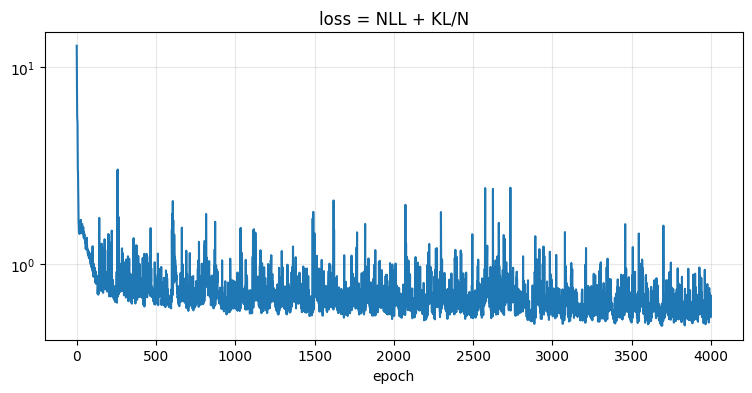

In [6]:
hist = model.fit(X, Y, epochs=4000, batch_size=N, verbose=0)
plt.plot(hist.history["loss"]); plt.yscale("symlog"); plt.title("loss = NLL + KL/N"); plt.xlabel("epoch"); plt.show()

## 4. Separating aleatoric and epistemic uncertainty

Each call `model(x)` draws new weights and returns a Normal distribution. With $T$ calls we get means $\mu_t(x)$ and standard deviations $\sigma_t(x)$. By the law of total variance:

$$\operatorname{Var}[y^*]=\underbrace{\tfrac1T\textstyle\sum_t\sigma_t(x)^2}_{\text{aleatoric}}+\underbrace{\operatorname{Var}_t\big[\mu_t(x)\big]}_{\text{epistemic}}.$$

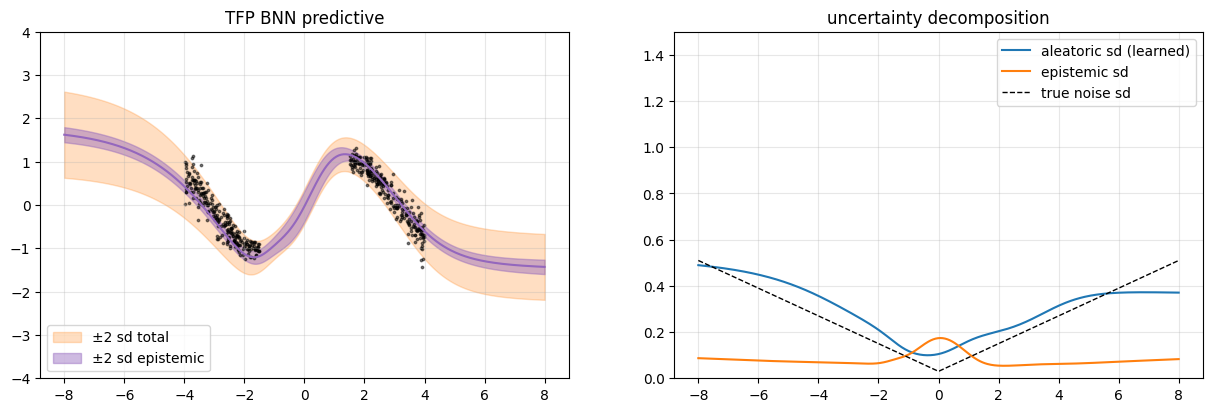

In [7]:
T = 200
means, sds = [], []
for _ in range(T):
    dist = model(xg)
    means.append(dist.mean().numpy().ravel()); sds.append(dist.stddev().numpy().ravel())
means, sds = np.array(means), np.array(sds)

mu = means.mean(0)
alea = np.sqrt((sds**2).mean(0))
epi = means.std(0)
total = np.sqrt(alea**2 + epi**2)
xs = xg.ravel()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].fill_between(xs, mu - 2 * total, mu + 2 * total, color="C1", alpha=0.25, label="±2 sd total")
ax[0].fill_between(xs, mu - 2 * epi, mu + 2 * epi, color="C4", alpha=0.45, label="±2 sd epistemic")
ax[0].plot(xs, mu, c="C4"); ax[0].scatter(x, y, s=3, c="k", alpha=0.5)
ax[0].set_ylim(-4, 4); ax[0].legend(loc="lower left"); ax[0].set_title("TFP BNN predictive")
ax[1].plot(xs, alea, label="aleatoric sd (learned)"); ax[1].plot(xs, epi, label="epistemic sd")
ax[1].plot(xs, 0.03 + 0.06 * np.abs(xs), "k--", lw=1, label="true noise sd")
ax[1].set_ylim(0, 1.5); ax[1].legend(); ax[1].set_title("uncertainty decomposition")
plt.show()

Inside the data (1.5 < |x| < 4) the learned aleatoric curve rises with |x| roughly like the true noise level. Outside, the aleatoric values are pure extrapolation. The **epistemic** part is the one that should signal missing data — here it grows only slightly, which is the familiar over-confidence of mean-field VI with a small network (compare MCMC in notebook 05). Try exercise 2, or widen the posterior initialisation, and watch how sensitive this is.

## 5. Other TFP tools
* `tfpl.DenseFlipout` / `tfpl.DenseReparameterization` — variational layers with lower-variance gradient estimators; convolutional versions exist too (`Convolution2DFlipout`).
* `tfp.mcmc` — HMC and NUTS samplers, if you want to redo notebook 05 in TensorFlow.
* The official TFP example *"Probabilistic Layers Regression"* walks through the same aleatoric/epistemic progression.

## Exercises
1. Replace `DenseVariational` by `tfpl.DenseFlipout` (it takes `kernel_divergence_fn=lambda q, p, _: tfd.kl_divergence(q, p) / N`).
2. Make the prior trainable (an *empirical Bayes* prior) using `tfpl.VariableLayer` for its mean. What happens to the uncertainty?
3. Change the output to a Student-t distribution (`tfd.StudentT`). When would heavy tails help?